In [7]:
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
from matplotlib import cm
import studyparams as params, os, funcs
from jaratoolbox import celldatabase, settings
import numpy as np

# Load dataframe
AM_arrays = np.load(params.dbSavePath + "/fr_arrays_AM.npz")
AM_onset = AM_arrays['onsetfr']
AM_sustained = AM_arrays['sustainedfr']
AM_offset = AM_arrays['offsetfr']
AM_brain = AM_arrays['brainRegionArray']
AM_brain = AM_arrays['stimArray']
AM_mouse = AM_arrays['mouseIDArray']
AM_session = AM_arrays['sessionIDArray']
AM_onset

array([[-0.80168776, -0.80168776, -0.80168776, ...,  4.19831224,
        -0.80168776, -0.80168776],
       [ 2.53164557, -2.46835443, -2.46835443, ..., -2.46835443,
        -2.46835443,  2.53164557],
       [-2.93248945,  2.06751055,  2.06751055, ...,  2.06751055,
        -2.93248945,  2.06751055],
       ...,
       [-3.5021097 , -3.5021097 , -3.5021097 , ...,  1.4978903 ,
         6.4978903 , -3.5021097 ],
       [-1.01265823, -1.01265823, -1.01265823, ..., -1.01265823,
        -1.01265823,  3.98734177],
       [ 0.41484716, 15.41484716, -4.58515284, ..., 10.41484716,
         5.41484716,  0.41484716]], shape=(409, 220))

In [23]:
print(f"AM Onset Shape: {AM_onset.shape}")
print(f"AM Sustained Shape: {X_AM_dict['sustained'].shape}")
print(f"AM Offset Shape: {X_AM_dict['offset'].shape}")

print(f"PT Onset Shape: {X_PT_dict['onset'].shape}")
print(f"PT Sustained Shape: {X_PT_dict['sustained'].shape}")
print(f"PT Offset Shape: {X_PT_dict['offset'].shape}")

print(f"Speech Onset Shape: {X_speech_dict['onset'].shape}")
print(f"Speech Sustained Shape: {X_speech_dict['sustained'].shape}")
print(f"Speech Offset Shape: {X_speech_dict['offset'].shape}")

AM Onset Shape: (557, 220)
AM Sustained Shape: (557, 220)
AM Offset Shape: (557, 220)
PT Onset Shape: (431, 640)
PT Sustained Shape: (431, 640)
PT Offset Shape: (431, 640)
Speech Onset Shape: (400, 381)
Speech Sustained Shape: (400, 381)
Speech Offset Shape: (400, 381)


In [24]:
data_dict = {}

for brain_area in params.targetSiteNames:
    for window_name in X_speech_dict:
        brain_area_mask = np.array(Y_brain_area_speech_all_renamed[window_name]) == brain_area
        X_array = X_speech_dict[window_name][brain_area_mask].T
        data_dict[(brain_area, 'speech', window_name)] = {'X': X_array, 'Y': Y_frequency_speech_sorted}

    for window_name in X_AM_dict:
        brain_area_mask = np.array(Y_brain_area_AM_all_renamed[window_name]) == brain_area
        X_array = X_AM_dict[window_name][brain_area_mask].T
        data_dict[(brain_area, 'AM', window_name)] = {'X': X_array, 'Y': Y_frequency_AM_sorted}

    for window_name in X_PT_dict:
        brain_area_mask = np.array(Y_brain_area_PT_all_renamed[window_name]) == brain_area
        X_array = X_PT_dict[window_name][brain_area_mask].T
        data_dict[(brain_area, 'PT', window_name)] = {'X': X_array, 'Y': Y_frequency_PT_sorted}
        
data_dict[('Ventral auditory area', 'AM', 'onset')]['X'].shape

(220, 119)

## Principal Component Analysis and 2D PC Space Visualization

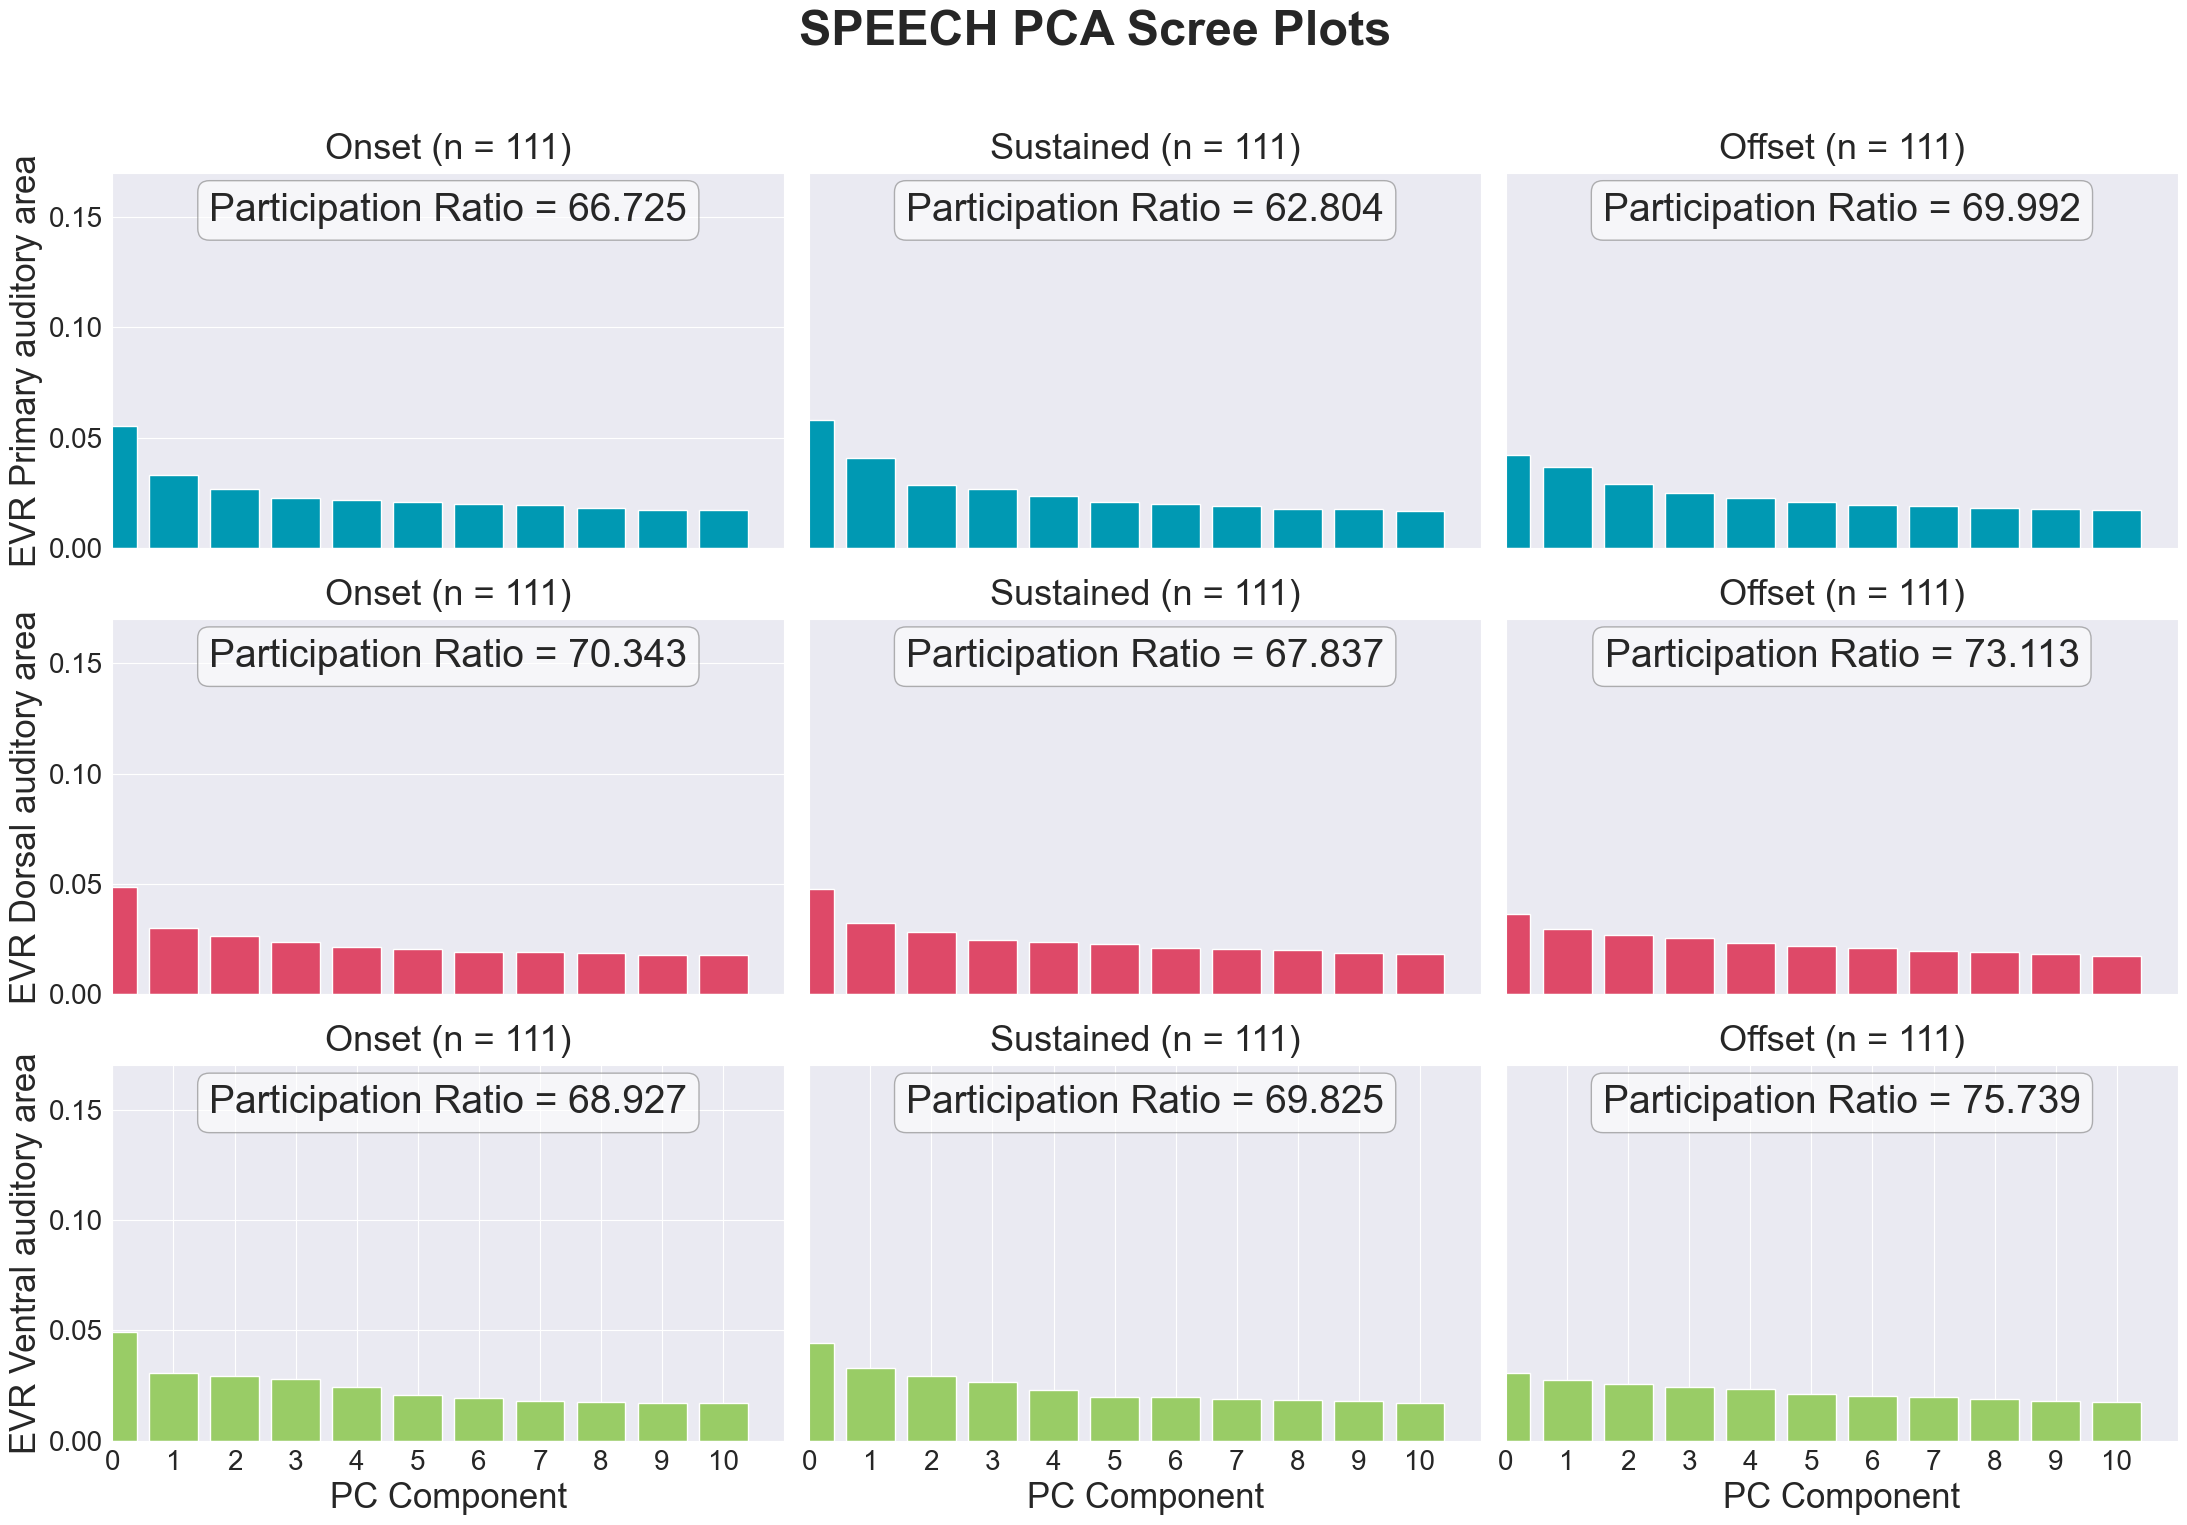

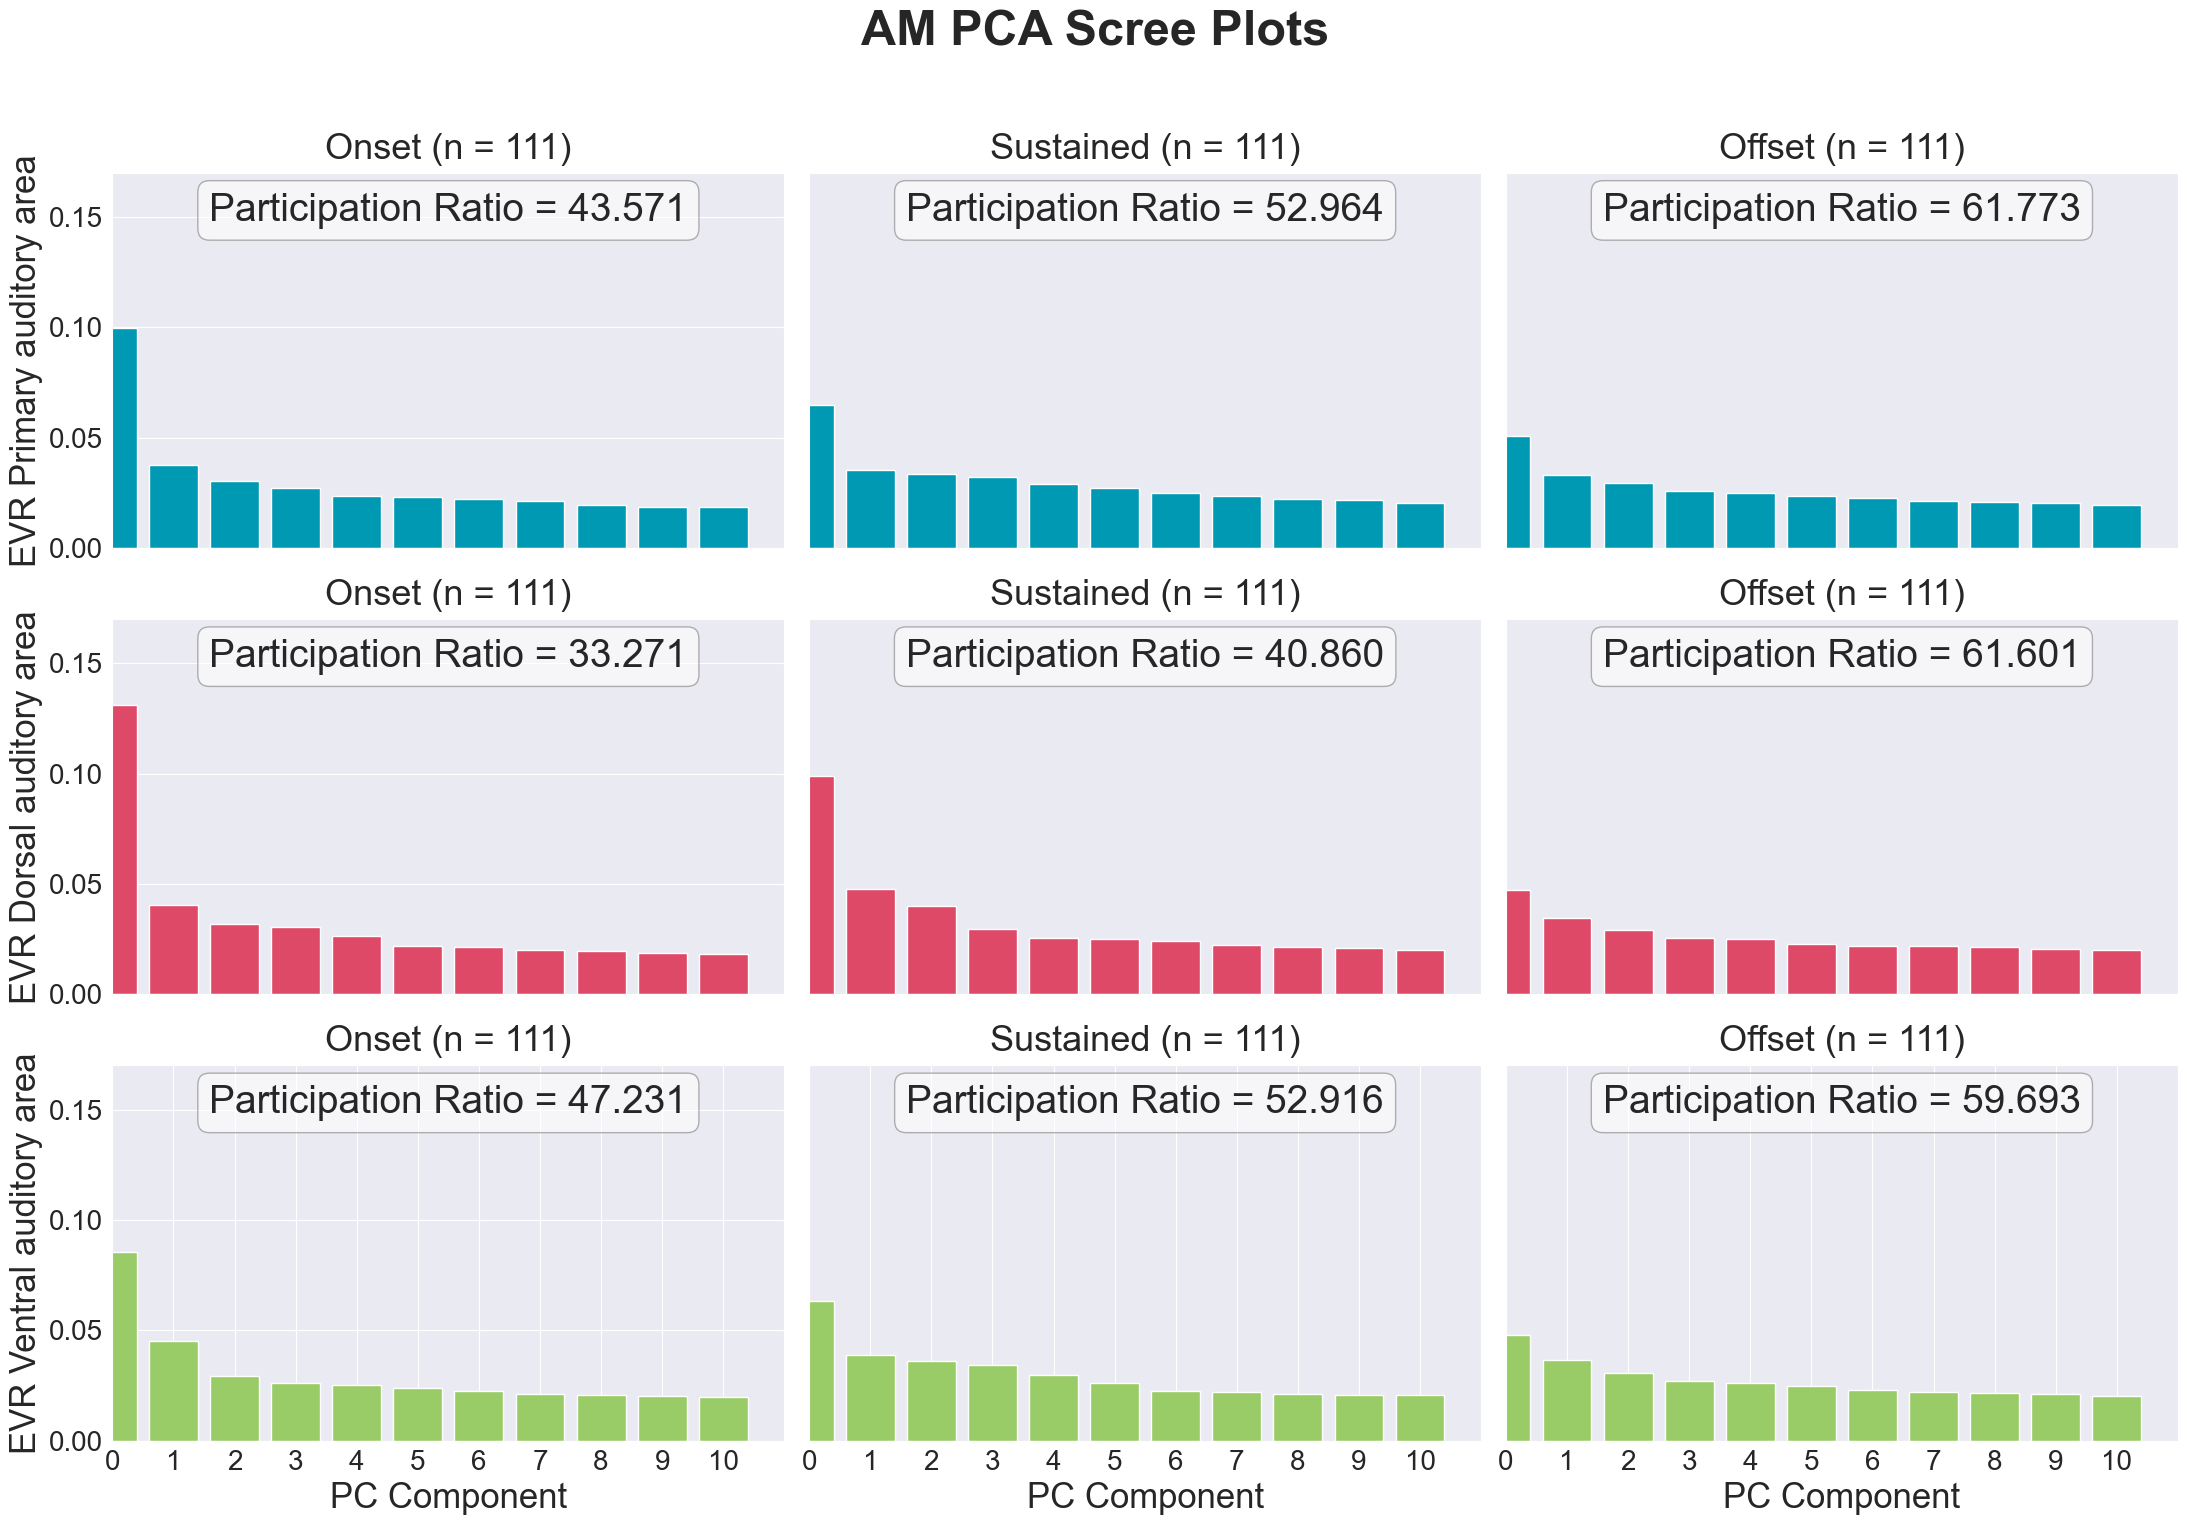

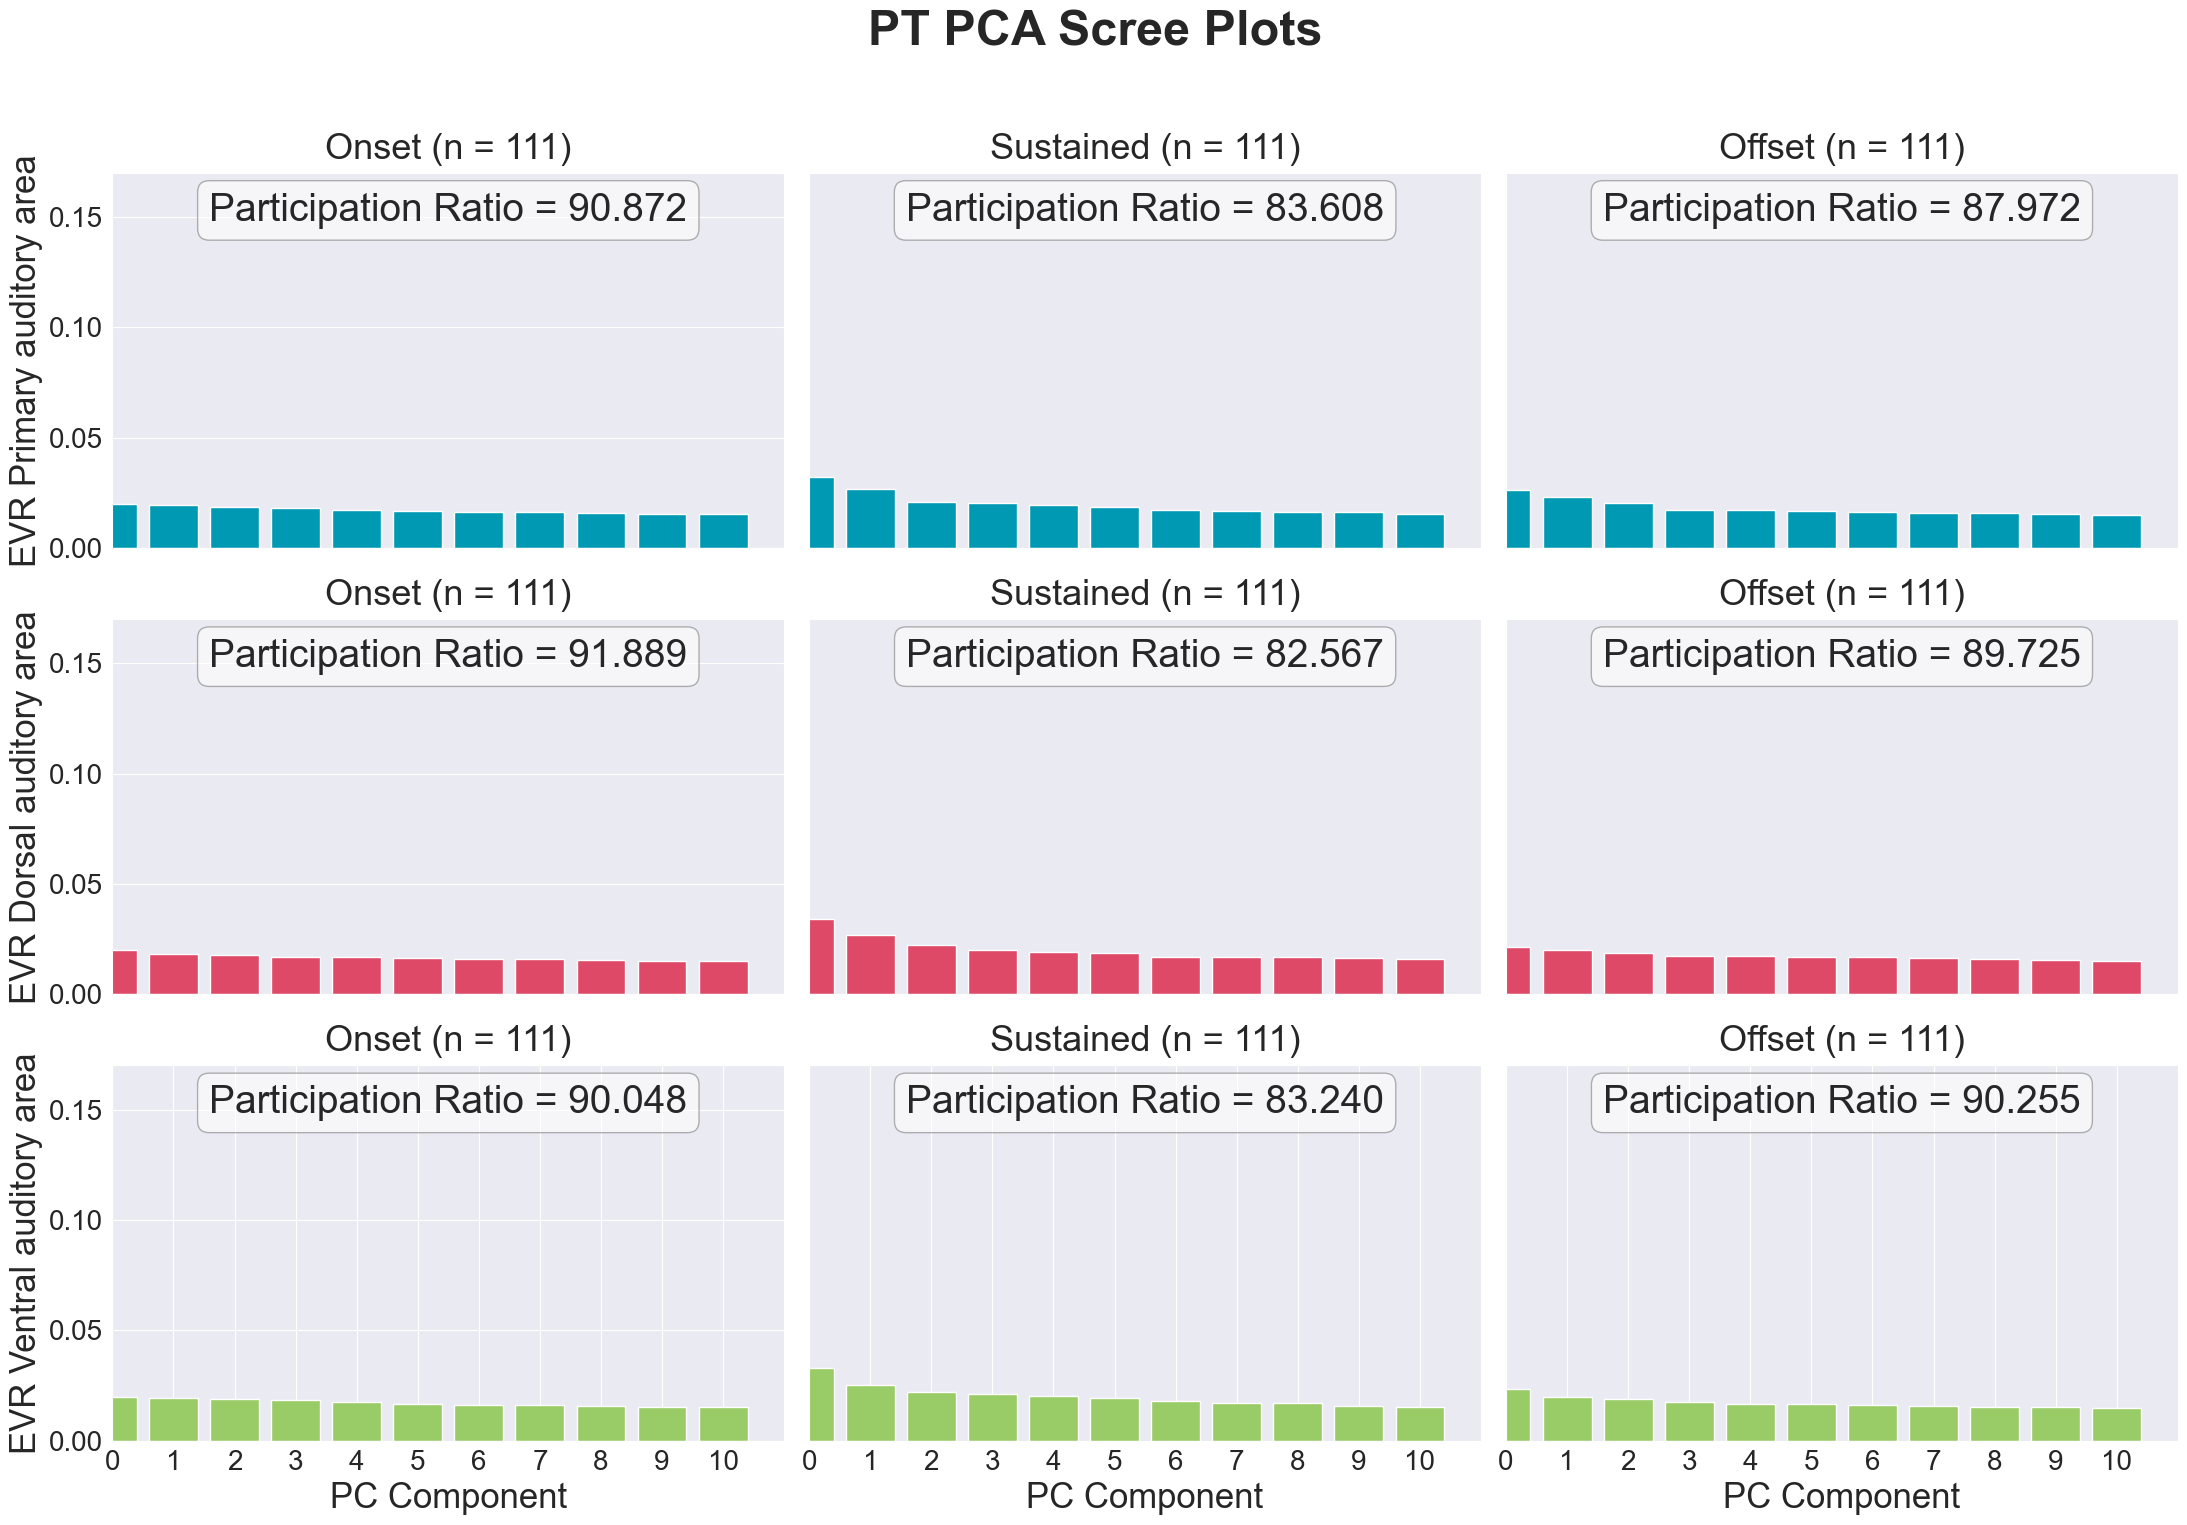

In [25]:
y_max = 0.17

for sound_type in ['speech', 'AM', 'PT']:
    fig, axes = plt.subplots(3, 3, figsize=(22, 16))
    fig.suptitle(f'{sound_type.upper()} PCA Scree Plots', fontweight='bold', fontsize=35)
    plt.subplots_adjust(hspace=0.4, wspace=0.3)

    for i, brain_area in enumerate(params.targetSiteNames):
        for j, window_name in enumerate(['Onset', 'Sustained', 'Offset']):
            ax = axes[i, j]
            key = (brain_area, sound_type, window_name)
            if key not in data_dict:
                ax.axis('off')
                continue

            data = data_dict[key]
            cmap = params.area_cmaps.get(brain_area, cm.viridis)
            X = data['X']
            n_neurons = X.shape[1]
            if n_neurons < 2:
                ax.axis('off')
                continue

            selected = np.random.choice(n_neurons, min(111, n_neurons), replace=False)
            X_sub = StandardScaler().fit_transform(X[:, selected])

            pca = PCA()
            pca.fit(X_sub)
            explained = pca.explained_variance_ratio_
            pr = funcs.calculate_participation_ratio(explained)

            funcs.plot_scree_plot(ax, X_sub, title=None, y_max=y_max, particRatio=pr, color=cmap(0.6))

            # X-axis label on bottom row
            if i == 2:
                ax.set_xlabel("PC Component", fontsize=25)
            else:
                ax.set_xticklabels([])
                ax.set_xticks([])

            # Y-axis label on left column
            if j == 0:
                ax.set_ylabel(f"EVR {brain_area}", fontsize=25)
            else:
                ax.set_yticklabels([])
                ax.set_yticks([])

            # Title per cell: "Window (n = X)"
            ax.set_title(f"{window_name.capitalize()} (n = {111})", fontsize=26, pad=10)

            ax.tick_params(axis='both', labelsize=20)

    fig.tight_layout(rect=[0, 0.03, 1, 0.95])
    plt.savefig(os.path.join(params.figSavePath, f'{sound_type} PCA Scree Plots'), bbox_inches='tight')
    plt.show()

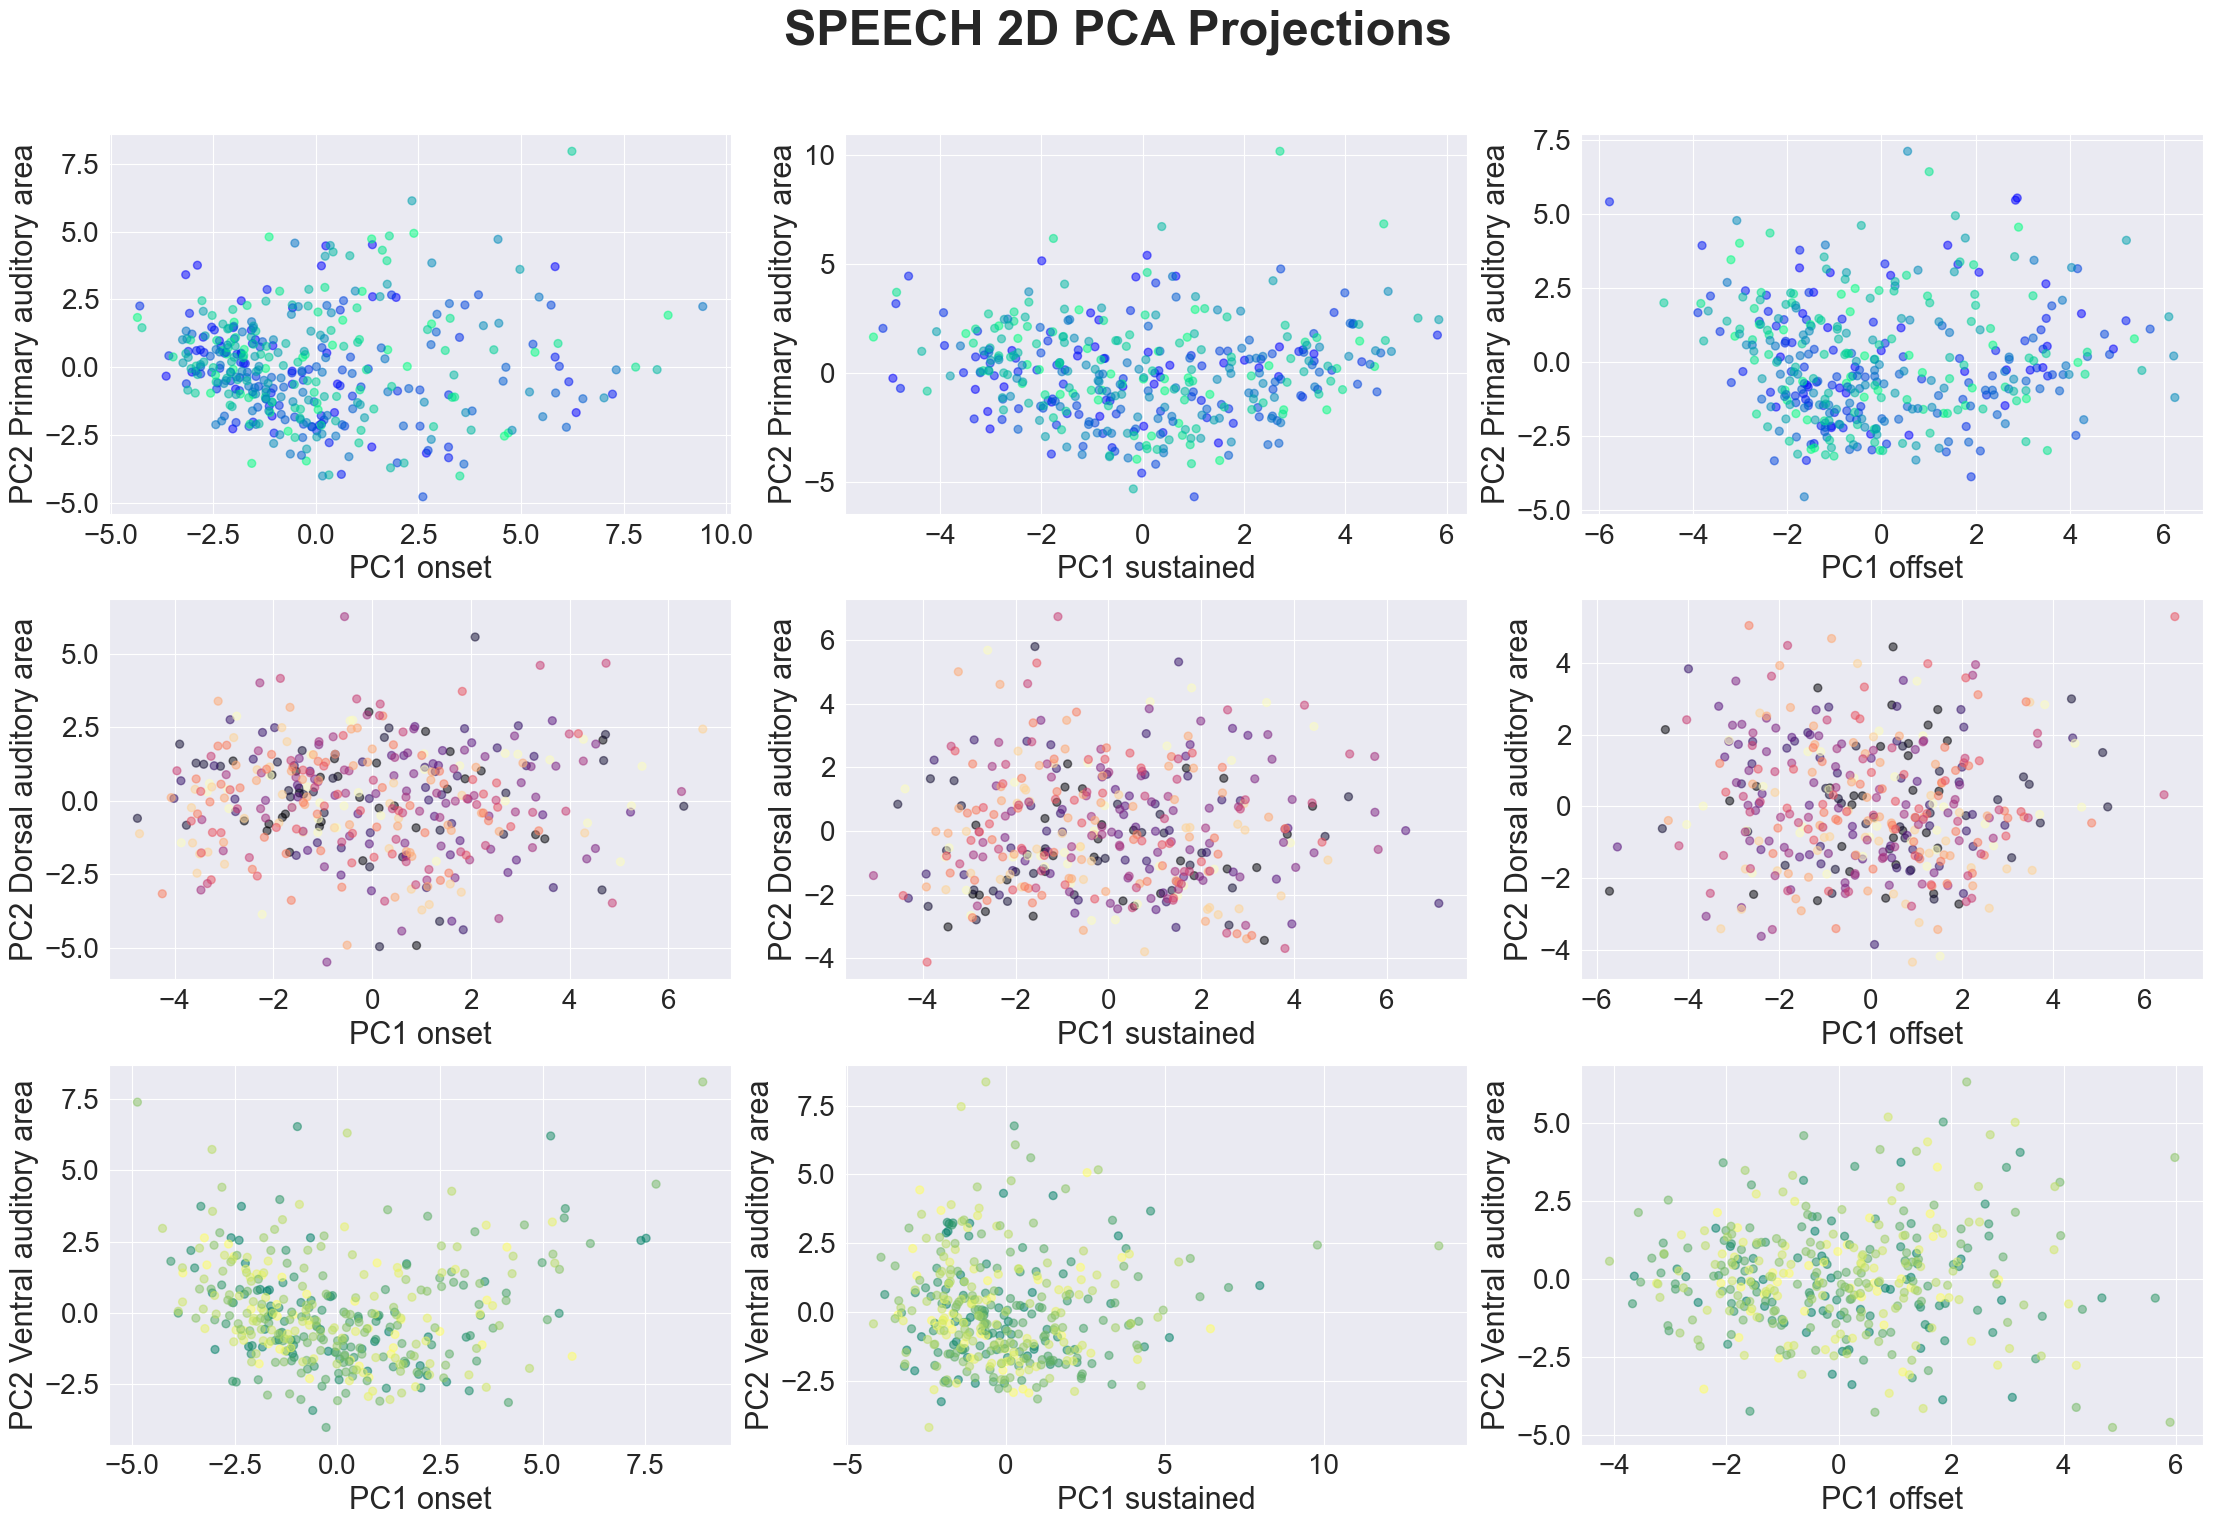

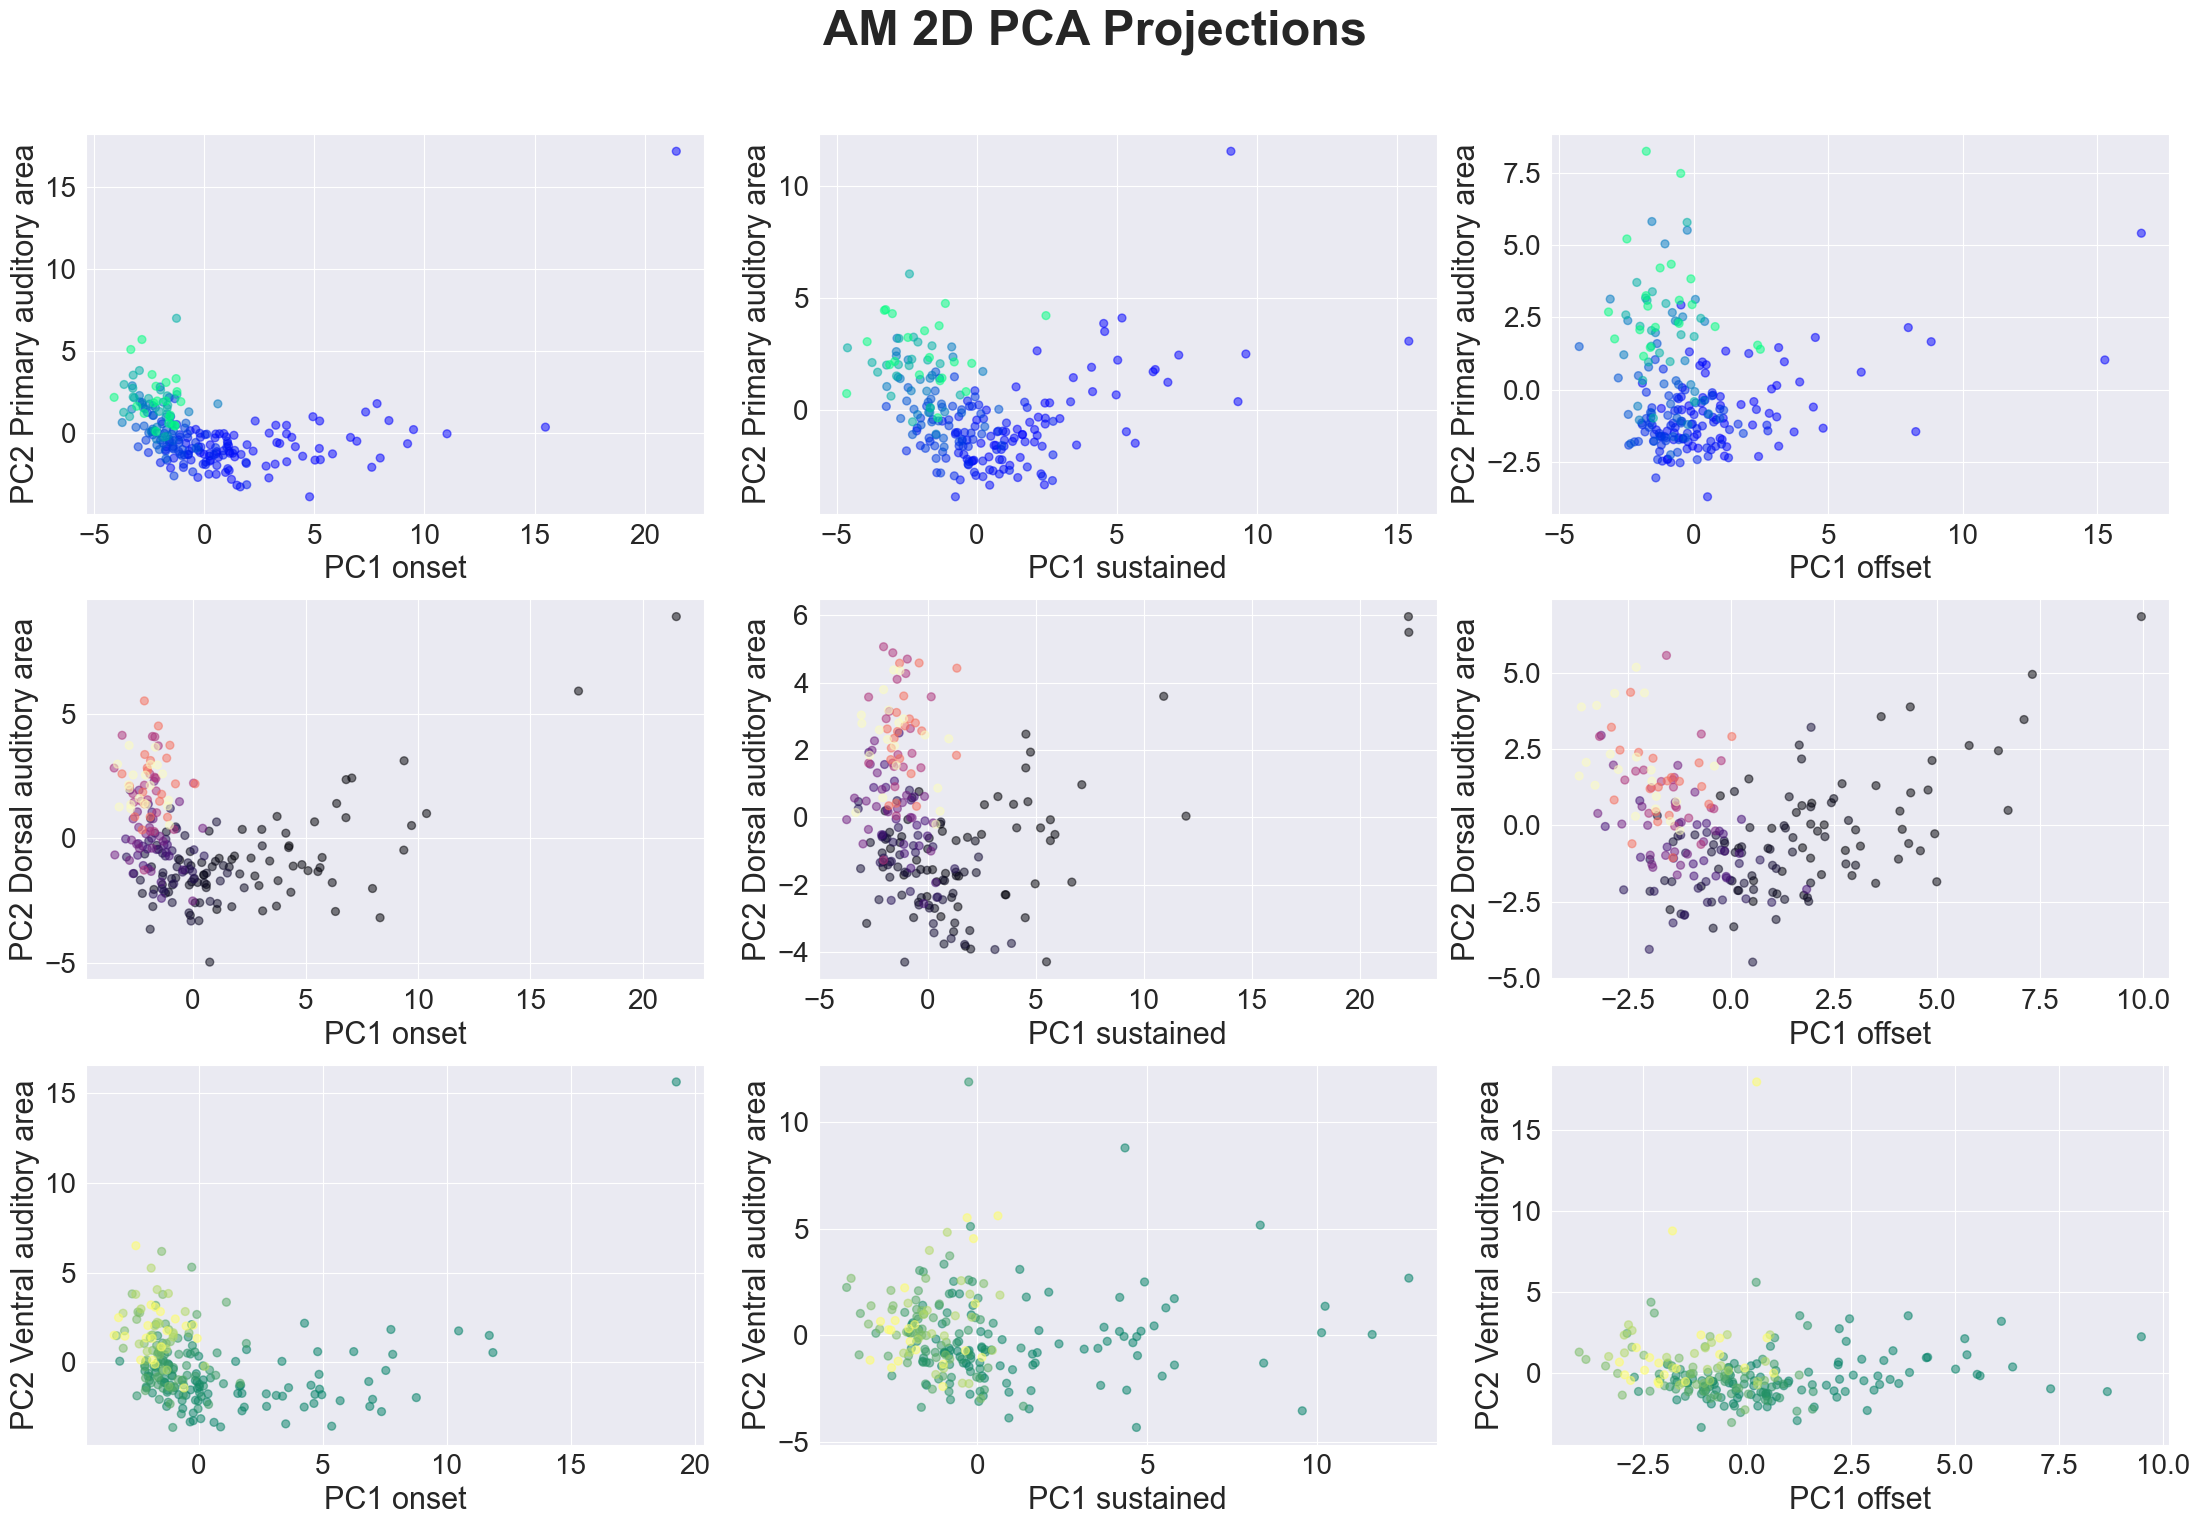

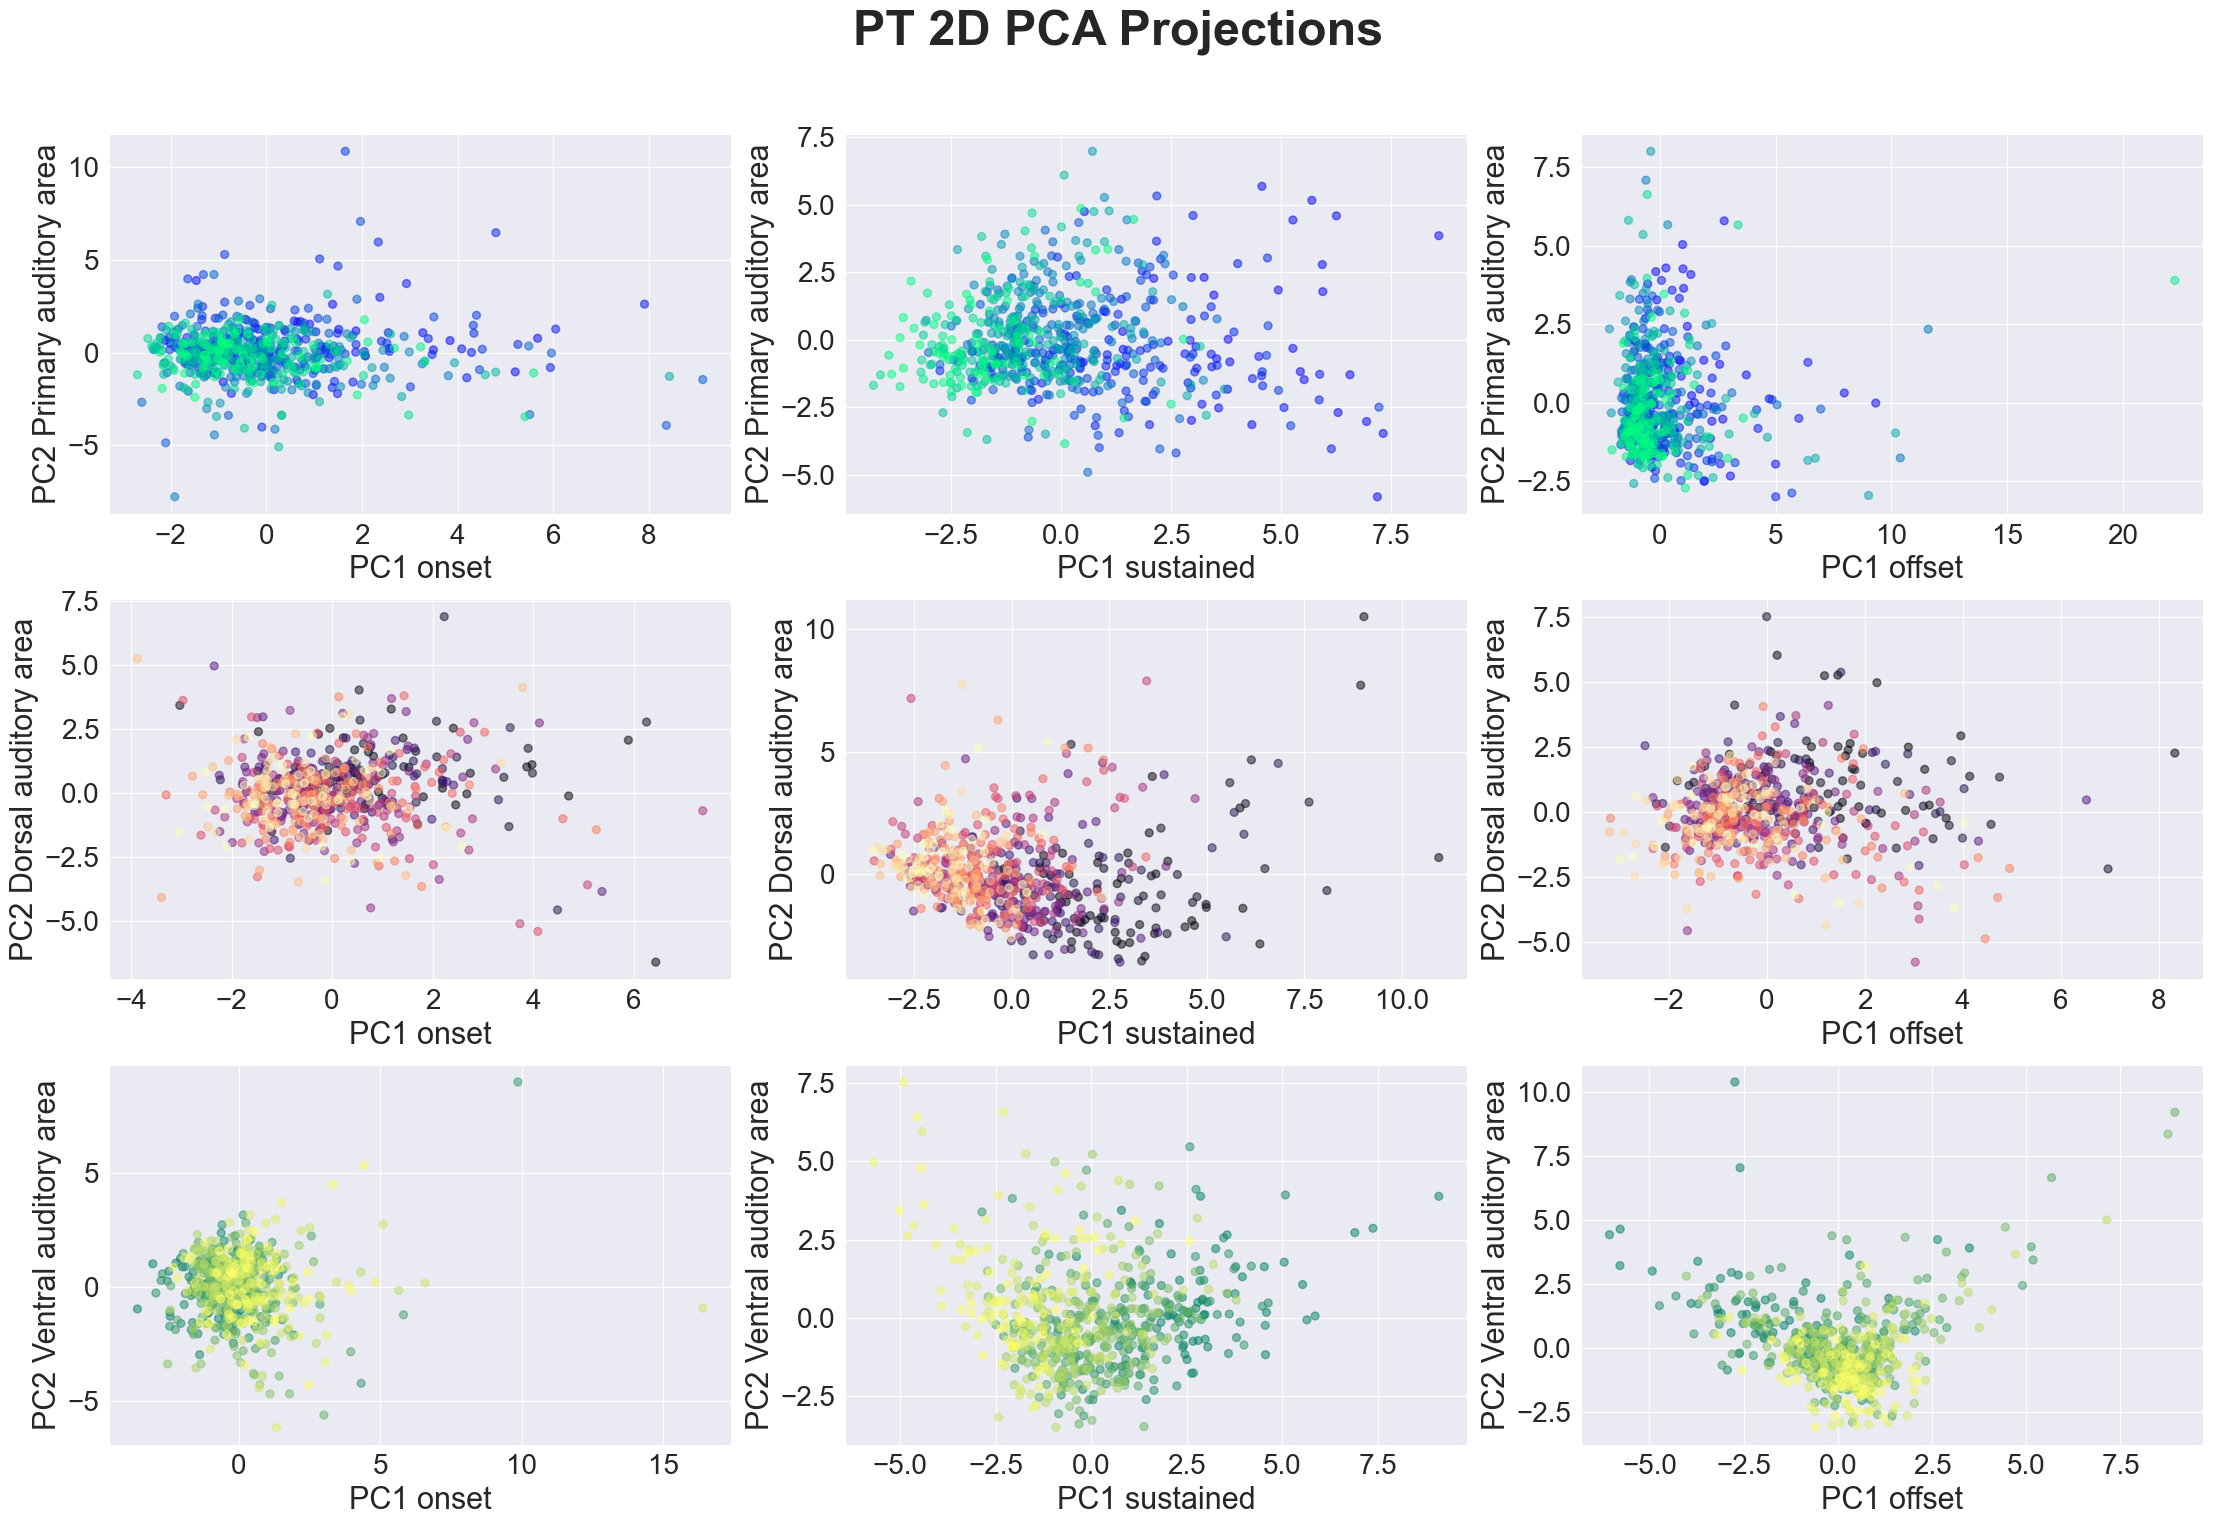

In [26]:
figsize = (22, 16)

for sound_type in ['speech', 'AM', 'PT']:
    fig, axes = plt.subplots(3, 3, figsize=figsize)
    fig.suptitle(f'{sound_type.upper()} 2D PCA Projections', fontweight='bold', fontsize=35)
    plt.subplots_adjust(hspace=0.4, wspace=0.3)

    for i, brain_area in enumerate(params.targetSiteNames):
        for j, window_name in enumerate(['Onset', 'Sustained', 'Offset']):
            ax = axes[i, j]
            key = (brain_area, sound_type, window_name)
            if key not in data_dict:
                ax.axis('off')
                continue

            data = data_dict[key]
            cmap = params.area_cmaps.get(brain_area, cm.viridis)
            X = data['X']
            if X.shape[1] < 2:
                ax.axis('off')
                continue

            selected = np.random.choice(X.shape[1], min(111, X.shape[1]), replace=False)
            X_sub = StandardScaler().fit_transform(X[:, selected])

            # Define color values
            if sound_type == 'speech':
                Y_labels = [tuple(row) for row in data['Y']]
                label_map = {(0,0):0, (0,33):1, (0,67):2, (0,100):3, (33,100):4, (67,100):5,
                             (100,100):6, (100,67):7, (100,33):8, (100,0):9, (67,0):10, (33,0):11}
                color_values = np.array([label_map.get(y, -1) for y in Y_labels])
            elif sound_type == 'PT':
                color_values = np.log10(data['Y'])
            else:
                color_values = data['Y']

            title = f"{brain_area.replace(' auditory area', '')} - {window_name.capitalize()}"
            funcs.plot_2d_pca(ax, {'X': X_sub, 'Y': data['Y']}, color_values, title, cmap=cmap)

            ax.tick_params(axis='both', labelsize=20)
            ax.set_xlabel(f"PC1 {window_name}", fontsize=22)
            ax.set_ylabel(f"PC2 {brain_area}", fontsize=22)

    fig.tight_layout(rect=[0, 0.03, 1, 0.95])
    plt.savefig(os.path.join(params.figSavePath, f'{sound_type} 2D PCA Projections'), bbox_inches='tight')
    plt.show()